# 03_CIFAR100_Hierarchical_Classification

Gonzalo Cazorla Sánchez

CIFAR100 es un conjunto de datos con dos niveles de etiquetado. Un etiquetado *fino* con 100 clases y un etiquetado *grueso* con 20 superclases. Se desea un sistema basado en neuronas lineales que tenga capacidad para realizar el etiquetado *fino*, pero se propone estudiar si la información que da el etiquetado *grueso* puede ayudar en la tarea aprovechando la probabilidad condicionada:

$$P(A|B) = \frac{P(A \cap B)}{P(B)}$$

Se espera una comparación entre la aproximación que usa solo un modelo neuronal para el etiquetado *fino* y la aproximación que incluye información del etiquetado *grueso*.

Información del conjunto de datos:

https://www.cs.toronto.edu/~kriz/cifar.html

Se espera el uso de las herramientas pertinentes tanto para completar el código como para realizar experimentos de los que se puedan extraer conclusiones sobre la capacidad del modelo entrenado. En el cuaderno se deben incluir los experimentos más relevantes.

Como conjunto de test se debe usar el conjunto de test íntegro que provee el conjunto de datos.

El cuaderno entregado debe llamarse ApellidosNombrePractica2Ejercicio2.ipynb

Consejos:
*  Cambiar el optimizador SGD por Adam. Lo veremos en clase próximamente :)
*  Normalizar los colores de las imágenes al rango [0,1].

In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset, Dataset
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import torch.nn.functional as F
import torchvision.transforms.functional as Fn
import numpy as np
import os
import csv
import tarfile
import pickle

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
workpath = '/content/drive/MyDrive/PIA/PRACTICA2EJ2'

Mounted at /content/drive


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando dispositivo: {device}')

Usando dispositivo: cuda


In [ ]:
tar_path = os.path.join(workpath, "cifar-100-python.tar.gz")
data_dir = os.path.join(workpath, "cifar-100-python")         # Carpeta donde se extraerán

print(f"Buscando archivo en: {tar_path}")

# Comprobamos si el directorio de DATOS (el resultado) ya existe
if os.path.exists(data_dir):
    print(f"El directorio '{data_dir}' ya existe. No es necesario descomprimir.")

# Si no existe, comprobamos si el .tar.gz (el input) está
elif os.path.exists(tar_path):
    print(f"Archivo .tar.gz encontrado. Descomprimiendo...")

    # Abrimos el archivo .tar.gz en modo lectura ('r:gz')
    with tarfile.open(tar_path, 'r:gz') as tar:
        # Extraemos todo en el 'workpath'
        tar.extractall(path=workpath)

    print(f"Extracción completada. Datos listos en: {data_dir}")

Buscando archivo en: /content/drive/MyDrive/PIA/PRACTICA2EJ2/cifar-100-python.tar.gz
El directorio '/content/drive/MyDrive/PIA/PRACTICA2EJ2/cifar-100-python' ya existe. No es necesario descomprimir.


In [ ]:
def unpickle(file):
    with open(file, 'rb') as fo:
        # Usamos 'bytes' encoding como dice la web de CIFAR
        dict = pickle.load(fo, encoding='bytes')
    return dict

# Definimos las rutas a los archivos descomprimidos
train_file = os.path.join(data_dir, 'train')
test_file = os.path.join(data_dir, 'test')
meta_file = os.path.join(data_dir, 'meta')

# Cargamos los diccionarios (si los archivos existen)
if os.path.exists(train_file) and os.path.exists(test_file):
    train_dict = unpickle(train_file)
    test_dict = unpickle(test_file)
    meta_dict = unpickle(meta_file)

    print("Archivos 'pickle' cargados:")
    # Imprimimos las claves para verificar (convertidas de bytes a string)
    print(f"Train keys: {[key.decode('utf-8') for key in train_dict.keys()]}")
    print(f"Test keys: {[key.decode('utf-8') for key in test_dict.keys()]}")
    print(f"Meta keys: {[key.decode('utf-8') for key in meta_dict.keys()]}")

Archivos 'pickle' cargados:
Train keys: ['filenames', 'batch_label', 'fine_labels', 'coarse_labels', 'data']
Test keys: ['filenames', 'batch_label', 'fine_labels', 'coarse_labels', 'data']
Meta keys: ['fine_label_names', 'coarse_label_names']


In [ ]:
# Extraer Datos a Numpy

# --- Datos de Entrenamiento (50000) ---
# Claves en bytes (b'data', b'fine_labels', b'coarse_labels')
data_train_np = train_dict[b'data']
labels_fine_train_np = np.array(train_dict[b'fine_labels'])
labels_coarse_train_np = np.array(train_dict[b'coarse_labels'])

# --- Datos de Test (10000) ---
data_test_np = test_dict[b'data']
labels_fine_test_np = np.array(test_dict[b'fine_labels'])
labels_coarse_test_np = np.array(test_dict[b'coarse_labels'])

print(f"Shape datos Train (raw): {data_train_np.shape}")
print(f"Shape datos Test (raw): {data_test_np.shape}")

Shape datos Train (raw): (50000, 3072)
Shape datos Test (raw): (10000, 3072)


In [ ]:
# Reformatear Datos
# Los datos están guardados como (N, 3072) en formato (N, 1024_R + 1024_G + 1024_B).
# Necesitamos reformatearlos a (N, 3, 32, 32)
data_train_reshaped = data_train_np.reshape(50000, 3, 32, 32)
data_test_reshaped = data_test_np.reshape(10000, 3, 32, 32)

# 2. Transponemos de (N, C, H, W) a (N, H, W, C)
# Esto es VITAL porque 'transforms.ToTensor' (que nos normaliza [0,1]) espera que
# los canales (C) estén en la ÚLTIMA dimensión para convertirlo de Numpy a Tensor.
data_train = data_train_reshaped.transpose(0, 2, 3, 1)
data_test = data_test_reshaped.transpose(0, 2, 3, 1)

print(f"Shape datos Train (HWC): {data_train.shape}")
print(f"Shape datos Test (HWC): {data_test.shape}")

Shape datos Train (HWC): (50000, 32, 32, 3)
Shape datos Test (HWC): (10000, 32, 32, 3)


In [ ]:
class ManualCIFAR100(Dataset):
    def __init__(self, data_np, fine_labels_np, coarse_labels_np, transform=None):
        self.data = data_np
        self.fine_labels = fine_labels_np
        self.coarse_labels = coarse_labels_np
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Cogemos los datos numpy
        img = self.data[idx]
        label_f = self.fine_labels[idx]
        label_c = self.coarse_labels[idx]

        # Aplicamos las transformaciones (importante: toTensor)
        if self.transform:
            img = self.transform(img)

        return img, label_f, label_c

In [ ]:
# Aplicar Transforms y Dividir Train/Val

# Política de aumentación (ToTensor es obligatorio aquí)
augmentation_policy = transforms.Compose([
    transforms.ToTensor(),                  # Convierte (H,W,C) [0-255] a (C,H,W) [0-1]
    transforms.RandomHorizontalFlip(p=0.5)
])

# 1. Crear los datasets base (en CPU, aplicando transforms)
train_dataset_base = ManualCIFAR100(data_train, labels_fine_train_np, labels_coarse_train_np, transform=augmentation_policy)
test_dataset = ManualCIFAR100(data_test, labels_fine_test_np, labels_coarse_test_np, transform=transforms.ToTensor())

# 2. Dividir Train/Val (10%)
full_size = len(train_dataset_base)
val_size = int(full_size * 0.1)
train_size = full_size - val_size

train_dataset, val_dataset = torch.utils.data.random_split(train_dataset_base, [train_size, val_size])

print(f"División completada: {len(train_dataset)} (train) / {len(val_dataset)} (val)")
print(f"Test: {len(test_dataset)}")

División completada: 45000 (train) / 5000 (val)
Test: 10000


In [ ]:
print(f"Moviendo conjuntos de datos completos a {device}...")

def load_dataset_to_device(dataset, device):
    # Usamos un DataLoader temporal con batch_size=len(dataset)
    # para cargar TODO el dataset en un solo lote (es lo más rápido)
    loader = DataLoader(dataset, batch_size=len(dataset), shuffle=False)

    # Obtenemos ese único lote gigante
    data = next(iter(loader))
    images = data[0].to(device)
    labels_fine = data[1].to(device)
    labels_coarse = data[2].to(device)

    print(f"  Imágenes: {images.shape} en {images.device}")
    print(f"  Etiquetas Finas: {labels_fine.shape} en {labels_fine.device}")
    print(f"  Etiquetas Gruesas: {labels_coarse.shape} en {labels_coarse.device}")

    # Creamos un nuevo Dataset que VIVE en la GPU
    return TensorDataset(images, labels_fine, labels_coarse)

train_dataset_gpu = load_dataset_to_device(train_dataset, device)
val_dataset_gpu = load_dataset_to_device(val_dataset, device)
test_dataset_gpu = load_dataset_to_device(test_dataset, device)

print(f"...Carga a {device} completada.")

Moviendo conjuntos de datos completos a cuda...
  Imágenes: torch.Size([45000, 3, 32, 32]) en cuda:0
  Etiquetas Finas: torch.Size([45000]) en cuda:0
  Etiquetas Gruesas: torch.Size([45000]) en cuda:0
  Imágenes: torch.Size([5000, 3, 32, 32]) en cuda:0
  Etiquetas Finas: torch.Size([5000]) en cuda:0
  Etiquetas Gruesas: torch.Size([5000]) en cuda:0
  Imágenes: torch.Size([10000, 3, 32, 32]) en cuda:0
  Etiquetas Finas: torch.Size([10000]) en cuda:0
  Etiquetas Gruesas: torch.Size([10000]) en cuda:0
...Carga a cuda completada.


In [ ]:
batch_size = 1024
learning_rate = 1e-4
epochs = 200
loss_fn = torch.nn.NLLLoss()
optimizer = torch.optim.Adam
validation_freq = 5
patience = 10
delta = 0.001

# --- Creamos los DataLoaders (usando los nuevos datasets en GPU) ---
train_loader = DataLoader(train_dataset_gpu, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset_gpu, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset_gpu, batch_size=batch_size, shuffle=False)

# Definimos las dimensiones
input_size = 3 * 32 * 32  # 3072
hidden_size = 64
num_clases_fine = 100     # CIFAR100 tiene 100 clases finas
num_clases_coarse = 20    # CIFAR100 tiene 20 clases finas

In [ ]:
class Early_Stop():
  def __init__(self, patience=5, delta=0):
    self.patience = patience
    self.delta = delta
    self.best_val_loss = None
    self.no_val_improvement_times = 0
    self.stop = False

  def check_stop(self, val_loss):
    if self.best_val_loss is None or (val_loss + self.delta) < self.best_val_loss:
      self.best_val_loss = val_loss
      self.no_val_improvement_times = 0
    else:
      self.no_val_improvement_times += 1
      self.stop = self.no_val_improvement_times >= self.patience

In [ ]:
def learning_loop_for_classification_with_early_stopping(train_dataloader, val_dataloader, model, epochs, loss_fn, learning_rate, optimizer, validation_freq, early_stop, label_index):
  epoch_loss_list = []
  val_loss_list = []
  val_acc_list = []

  opt = optimizer(
    model.parameters(),
    lr=learning_rate
  )

  with tqdm(range(epochs), desc="epoch:") as pbar:

    # --- Bucle de Entrenamiento ---
    for epoch in pbar:
      steps_loss_list = []
      for data_batch in train_dataloader:
        x_true = data_batch[0]
        y_true = data_batch[label_index]                    # Usamos el índice para elegir la etiqueta

        y_pred = model(x_true)                              # Forward
        opt.zero_grad()
        loss = loss_fn(y_pred, y_true)
        loss.backward()                                     # Backward
        steps_loss_list.append(loss.clone().detach().cpu())
        opt.step()
      train_loss = torch.tensor(steps_loss_list).mean()
      epoch_loss_list.append(train_loss)
      pbar.set_postfix(loss=f"{train_loss}")

      # --- Validación ---
      if epoch%validation_freq==0:
        val_step_loss_list = []
        val_correct_answers = 0
        val_set_size = 0
        with torch.no_grad():
          for data_batch_val in val_dataloader:
            x_val_true = data_batch_val[0]
            y_val_true = data_batch_val[label_index]        # Volvemos a usar el índice

            y_val_pred = model(x_val_true)
            loss_val = loss_fn(y_val_pred, y_val_true)
            val_step_loss_list.append(loss_val.cpu())

            correct_answers = torch.sum(y_val_true==torch.argmax(y_val_pred, dim=-1))
            val_correct_answers += correct_answers
            val_set_size += y_val_true.numel()

          val_loss = torch.tensor(val_step_loss_list).mean()
          val_loss_list.append(val_loss)
          val_acc = val_correct_answers.float() / float(val_set_size)
          val_acc_list.append(val_acc.cpu())


        early_stop.check_stop(val_loss)
        if early_stop.stop:
          print("Early Stop.")
          break

  print(f"--- Entrenamiento finalizado ---")

  return model, epoch_loss_list, val_loss_list, val_acc_list

In [ ]:
# Modelo A (100 Clases)
model_A = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.Linear(input_size, hidden_size),
    torch.nn.LeakyReLU(),
    torch.nn.Linear(hidden_size, num_clases_fine),    # 100 salidas
    torch.nn.LogSoftmax(dim=1)
).to(device)
print(f"Número de parámetros (Modelo A): {torch.tensor([p.numel() for p in model_A.parameters()]).sum()}")

# Modelo B (20 Clases Gruesas)
model_B = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.Linear(input_size, hidden_size),
    torch.nn.LeakyReLU(),
    torch.nn.Linear(hidden_size, num_clases_coarse),  # 20 salidas
    torch.nn.LogSoftmax(dim=1)
).to(device)
print(f"Número de parámetros (Modelo B): {torch.tensor([p.numel() for p in model_B.parameters()]).sum()}")

Número de parámetros (Modelo A): 203172
Número de parámetros (Modelo B): 197972


In [ ]:
# Ejecutar Entrenamiento (Modelo A)
early_stop_A = Early_Stop(patience = patience, delta = delta)

print(f"Iniciando entrenamiento (Modelo A: 100 Clases Finas) en {device}...")
model_A, train_loss_A, val_loss_A, val_acc_A = learning_loop_for_classification_with_early_stopping(
    train_loader,
    val_loader,
    model_A,
    epochs,
    loss_fn,
    learning_rate,
    optimizer,
    validation_freq,
    early_stop_A,
    label_index=1,     # USA LA ETIQUETA FINA (índice 1)
)

Iniciando entrenamiento (Modelo A: 100 Clases Finas) en cuda...


epoch:: 100%|██████████| 200/200 [02:07<00:00,  1.57it/s, loss=3.205164909362793]

--- Entrenamiento finalizado ---


In [ ]:
# Ejecutar Entrenamiento (Modelo B)

early_stop_B = Early_Stop(patience = patience, delta = delta)

print(f"Iniciando entrenamiento (Modelo B: 20 Clases Gruesas) en {device}...")

model_B, train_loss_B, val_loss_B, val_acc_B = learning_loop_for_classification_with_early_stopping(
    train_loader,
    val_loader,
    model_B,
    epochs,
    loss_fn,
    learning_rate,
    optimizer,
    validation_freq,
    early_stop_B,
    label_index=2,     # USA LA ETIQUETA GRUESA (índice 2)
)

Iniciando entrenamiento (Modelo B: 20 Clases Gruesas) en cuda...


epoch:: 100%|██████████| 200/200 [02:09<00:00,  1.55it/s, loss=2.0472192764282227]

--- Entrenamiento finalizado ---


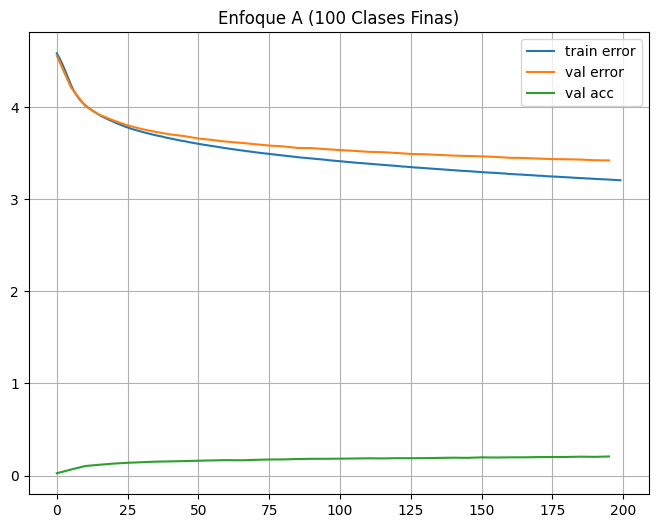


Accuracy Máxima de Validación (Modelo A): 0.208


In [ ]:
# Gráfica (Modelo A)

plt.figure(figsize=(8,6))
plt.title("Enfoque A (100 Clases Finas)")
plt.plot(range(len(train_loss_A)), train_loss_A, label="train error")
plt.plot(range(0, validation_freq*len(val_loss_A), validation_freq), val_loss_A, label="val error")
plt.plot(range(0, validation_freq*len(val_acc_A), validation_freq), val_acc_A, label="val acc")
plt.legend()
plt.grid(True)
plt.show()

print(f"\nAccuracy Máxima de Validación (Modelo A): {max(val_acc_A):.3f}")

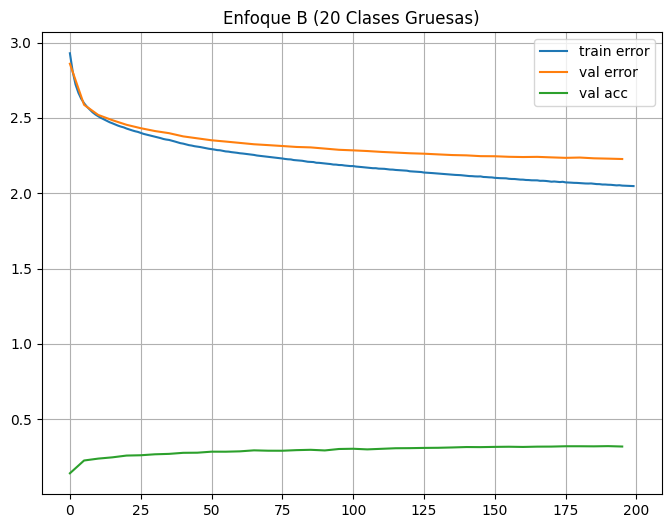


Accuracy Máxima de Validación (Modelo B): 0.321


In [ ]:
# Gráfica (Modelo B)

plt.figure(figsize=(8,6))
plt.title("Enfoque B (20 Clases Gruesas)")
plt.plot(range(len(train_loss_B)), train_loss_B, label="train error")
plt.plot(range(0, validation_freq*len(val_loss_B), validation_freq), val_loss_B, label="val error")
plt.plot(range(0, validation_freq*len(val_acc_B), validation_freq), val_acc_B, label="val acc")
plt.legend()
plt.grid(True)
plt.show()

print(f"\nAccuracy Máxima de Validación (Modelo B): {max(val_acc_B):.3f}")

In [ ]:
# Crear el Mapa de Clases Finas a Gruesas

# 100 entradas, donde cada índice es la clase FINA y el valor es la clase GRUESA correspondiente.
fine_to_coarse_map = torch.zeros(num_clases_fine, dtype=torch.long)

# Usamos el dataset original en CPU para construir el mapa. (No usamos el de GPU para no tener que moverlo de vuelta)
print("Construyendo mapa Fino -> Grueso...")

# Iteramos sobre los datos de entrenamiento originales
for i in range(len(train_dataset)):
    # No necesitamos la imagen, solo las etiquetas
    _, fine_label, coarse_label = train_dataset[i]
    # Guardamos el mapeo
    fine_to_coarse_map[fine_label] = coarse_label

# Movemos el mapa a la GPU para usarlo en el test
fine_to_coarse_map = fine_to_coarse_map.to(device)

print("Mapa completado.")
print(f"Ejemplo: Clase fina 0 ('apple') pertenece a la clase gruesa {fine_to_coarse_map[0]}")
print(f"Ejemplo: Clase fina 30 ('dolphin') pertenece a la clase gruesa {fine_to_coarse_map[30]}")
print(f"Shape del mapa: {fine_to_coarse_map.shape}")
print(f"El mapa: {fine_to_coarse_map}")

Construyendo mapa Fino -> Grueso...
Mapa completado.
Ejemplo: Clase fina 0 ('apple') pertenece a la clase gruesa 4
Ejemplo: Clase fina 30 ('dolphin') pertenece a la clase gruesa 0
Shape del mapa: torch.Size([100])
El mapa: tensor([ 4,  1, 14,  8,  0,  6,  7,  7, 18,  3,  3, 14,  9, 18,  7, 11,  3,  9,
         7, 11,  6, 11,  5, 10,  7,  6, 13, 15,  3, 15,  0, 11,  1, 10, 12, 14,
        16,  9, 11,  5,  5, 19,  8,  8, 15, 13, 14, 17, 18, 10, 16,  4, 17,  4,
         2,  0, 17,  4, 18, 17, 10,  3,  2, 12, 12, 16, 12,  1,  9, 19,  2, 10,
         0,  1, 16, 12,  9, 13, 15, 13, 16, 19,  2,  4,  6, 19,  5,  5,  8, 19,
        18,  1,  2, 15,  6,  0, 17,  8, 14, 13], device='cuda:0')


In [ ]:
# Bucle de Test (Comparativa A vs Combined)

# Contadores para ambos enfoques
correct_A = 0
correct_Combined = 0
total_samples = 0

print("Iniciando evaluación comparativa en el conjunto de Test...")

with torch.no_grad():
    for images, labels_fine, labels_coarse in test_loader:

        # --- 1. Obtener Predicciones de Ambos Modelos ---
        pred_log_A = model_A(images)
        pred_log_B = model_B(images)
        # Convertir a Probabilidades (0 a 1)
        probs_A = torch.exp(pred_log_A) # Shape: [batch_size, 100]
        probs_B = torch.exp(pred_log_B) # Shape: [batch_size, 20]

        # --- 2. Enfoque A (Línea Base) ---
        # Obtenemos la clase predicha (la más probable) del Modelo A
        pred_class_A = torch.argmax(probs_A, dim=1)

        # --- 3. Enfoque Combinado ---
        # Usamos el mapa para "expandir" las probabilidades de B de [batch_size, 20] a [batch_size, 100]
        probs_B_expanded = probs_B[:, fine_to_coarse_map] # Shape: [batch_size, 100]
        # Aplicamos la "función" (la probabilidad combinada) P(A ∩ B) / P(B) = P(A) / P(B)
        combined_probs = probs_A / probs_B_expanded
        # Obtenemos la clase predicha del modelo combinado
        pred_class_Combined = torch.argmax(combined_probs, dim=1)

        # --- 4. Calcular Aciertos ---
        correct_A += (pred_class_A == labels_fine).sum().item()
        correct_Combined += (pred_class_Combined == labels_fine).sum().item()

# --- 5. Mostrar Resultados ---
acc_A = correct_A / len(test_dataset)
acc_Combined = correct_Combined / len(test_dataset)

print("\n--- Resultados de la Comparación en Test ---")
print(f"Total de muestras de Test: {len(test_dataset)}")
print("=========================================================")
print(f"Accuracy Enfoque A (Línea Base): \t{acc_A * 100:.2f}%")
print(f"Accuracy Enfoque Combinado: \t\t{acc_Combined * 100:.2f}%")
print("=========================================================")

if acc_Combined > acc_A:
    print("¡Éxito! El Enfoque Asistido (B) ha mejorado la precisión.")
else:
    print("El Enfoque Combinado no ha mejorado la precisión del modelo base.")

Iniciando evaluación comparativa en el conjunto de Test...

--- Resultados de la Comparación en Test ---
Total de muestras de Test: 10000
Accuracy Enfoque A (Línea Base): 	20.70%
Accuracy Enfoque Combinado: 		2.80%
El Enfoque Combinado no ha mejorado la precisión del modelo base.


## Explicación de la Fórmula de Probabilidad Asistida

El objetivo de este ejercicio es ver si la información de la superclase (Modelo B) puede ayudar al modelo de la clase fina (Modelo A). Para ello, queremos combinar sus probabilidades.

---

### 1. ¿Por qué $P(A|B) = P(A \cap B) / P(B)$ es un enfoque erróneo?

La fórmula $P(A|B)$ (probabilidad de A *dado* B) es matemáticamente correcta, pero es **errónea si se usa como la puntuación final** para decidir la clase.

En el código anterior, calculamos esto como:

$$P(A|B) = \frac{P(A \cap B)}{P(B)} = \frac{P(A)_{\text{Modelo A}}}{P(B)_{\text{Modelo B}}}$$

*(Usando $P(A \cap B) = P(A)$ porque si algo es un "delfín" (A), ya está contenido en "mamífero acuático" (B)).*

Usar este valor como puntuación final tiene un problema grave:

- **Inestabilidad Numérica:** El denominador, $P(B)_{\text{Modelo B}}$, es la predicción del Modelo B. Si este modelo está *seguro* de que la imagen **NO** es la superclase $B$ (por ejemplo, $P(B) = 0.001$), pero el Modelo A cree que sí es la clase fina $A$ (por ejemplo, $P(A) = 0.1$), el resultado se dispara:
    
    $\text{Puntuación} = 0.1 / 0.001 = 100$
    
    Esta división **amplifica enormemente los errores** y el ruido de las predicciones, creando puntuaciones inestables y a menudo mayores que 1.
    
---

### 2. La Fórmula Correcta: $P(A) = P(A|B) \times P(B)$

Esta fórmula es la **Regla de la Cadena** de la probabilidad. Como $A \subset B$, sabemos que $P(A \cap B) = P(A)$. La fórmula nos dice cómo *debería* calcularse la probabilidad de $A$:

$$\text{Puntuación}(A) = P(A|B) \times P(B)$$

Aquí, descomponemos la puntuación final de la clase $A$ (lo que queremos predecir) en dos piezas que podemos estimar:

* **$P(B)$:** ¿Cuál es la probabilidad de que la imagen pertenezca a la *superclase* $B$?
    * **Fuente:** La predicción directa del **Modelo B**.
* **$P(A|B)$:** ¿Cuál es la probabilidad de que sea la clase fina $A$, *sabiendo* que estamos dentro de la superclase $B$?
    * **Fuente:** Esta es la parte clave, y la calculamos *renormalizando* las salidas del **Modelo A**.

Este enfoque es estable (es una multiplicación, no una división) y produce puntuaciones comparables en el rango [0, 1] para las 100 clases.

---

### 3. ¿Cómo obtenemos $P(A|B)$? (La Renormalización)

$P(A|B)$ *no* se calcula usando el Modelo B. Se calcula **usando solo el Modelo A**.

**Ejemplo para entenderlo:**

Si el Modelo A (para una imagen) da:
* $P(\text{gato}) = 0.4$
* $P(\text{perro}) = 0.2$
* $P(\text{pez}) = 0.3$
* $P(\text{ave}) = 0.1$

Y $B$ = "Mamífero" = {gato, perro}.

1.  $\text{Suma}_{\text{Mamífero}} = P(\text{gato}) + P(\text{perro}) = 0.4 + 0.2 = 0.6$
2.  $P(\text{gato} | \text{Mamífero}) = P(\text{gato}) / \text{Suma}_{\text{Mamífero}} = 0.4 / 0.6 = 0.66$
3.  $P(\text{perro} | \text{Mamífero}) = P(\text{perro}) / \text{Suma}_{\text{Mamífero}} = 0.2 / 0.6 = 0.33$

### Conclusión

La puntuación final (corregida) para cada clase fina $A$ se calcula como:

$$\text{Puntuación}(A) = \underbrace{ \left( \frac{P(A)_{\text{Modelo A}}}{\sum_{A' \in B} P(A')_{\text{Modelo A}}} \right) }_\text{ $P(A|B)$ (de Modelo A)} \times \underbrace{ P(B)_{\text{Modelo B}} }_\text{ $P(B)$ (de Modelo B) }$$

In [ ]:
# Bucle de Test (Comparativa A vs Combined - Fórmula Correcta)

# Contadores para ambos enfoques
correct_A = 0
correct_Combined = 0
total_samples = 0

print("Iniciando evaluación comparativa en el conjunto de Test (Fórmula Corregida)...")

with torch.no_grad():
    for images, labels_fine, labels_coarse in test_loader:

        # --- 1. Obtener Predicciones de Ambos Modelos ---
        pred_log_A = model_A(images)
        pred_log_B = model_B(images)
        # Convertir a Probabilidades (0 a 1)
        probs_A = torch.exp(pred_log_A) # Shape: [batch_size, 100]
        probs_B = torch.exp(pred_log_B) # Shape: [batch_size, 20]

        # --- 2. Enfoque A (Línea Base) ---
        # Obtenemos la clase predicha (la más probable) del Modelo A
        pred_class_A = torch.argmax(probs_A, dim=1)

        # --- 3. Enfoque Combinado ---
        # Usamos el mapa para "expandir" las probabilidades de B de [batch_size, 20] a [batch_size, 100]
        probs_B_expanded = probs_B[:, fine_to_coarse_map] # Shape: [batch_size, 100]

        # Calculamos la suma de normalización para P(A|B) (su denominador)

        # Usar el batch size actual (el último puede ser más pequeño)
        batch_size_actual = images.shape[0]
        # Creamos un tensor 'S_B' (Suma de B) de ceros, con forma [batch_size, 20], para que actúe como los 20 'cubos' donde acumularemos las sumas
        S_B = torch.zeros_like(probs_B)
        """[[0, 0, 0, ..., 0],
        ...,
        [0, 0, 0, ..., 0]]"""

        # Tomamos nuestro mapa [100] y lo 'expandimos' para que tenga la forma [batch_size, 100]. Ahora, para cada imagen del lote, tenemos un mapa que dice a qué superclase (0-19) pertenece cada clase fina (0-99).
        map_expanded = fine_to_coarse_map.expand(batch_size_actual, -1) # Shape [batch_size, 100]
        """[[4, 1, 14, ..., 8, 14, 13],
        ...,
        [4, 1, 14, ..., 8, 14, 13]]
        """

        # Suma las probabilidades finas (probs_A) en los "cubos" de las clases gruesas (index=map_expanded)
        S_B.scatter_add_(dim=1, index=map_expanded, src=probs_A)
        """[[6.7477e-02, 9.2744e-03, 1.0979e-03, ..., 5.1670e-03, 3.1362e-01, 7.2484e-02],
        ...
        [5.0598e-02, 3.7391e-02, 1.8918e-03,  ..., 1.3670e-02, 1.9340e-02, 8.2673e-03]]"""
        """ Para la Fila 0 (Imagen 0):
        Mira probs_A[0] (las 100 probabilidades de la imagen 0).
        Mira map_expanded[0] (el mapa para la imagen 0, que es [4, 1, 14, ...]).
        Toma probs_A[0][0] y lo suma en S_B[0][4].
        Toma probs_A[0][1] y lo suma en S_B[0][1].
        Toma probs_A[0][2] y lo suma en S_B[0][14].
        ...etc.
            Para la Fila 1 (Imagen 1):
        Mira probs_A[1] (las 100 probabilidades de la imagen 1).
        Mira map_expanded[1] (el mapa para la imagen 1, que es [4, 1, 14, ...]).
        Toma probs_A[1][0] y lo suma en S_B[1][4].
        Toma probs_A[1][1] y lo suma en S_B[1][1].
        Toma probs_A[1][2] y lo suma en S_B[1][14].
        ...etc."""


        # Usamos el mapa para "expandir" la suma S_B de [batch_size, 20] a [batch_size, 100]
        S_B_expanded = S_B[:, fine_to_coarse_map]

        # Calculamos P(A|B) = P(A) / (Suma de P(A) en B)
        prob_A_given_B = probs_A / S_B_expanded

        # Aplicamos la "NUEVA FÓRMULA" final: P(A) = P(A ∩ B) = P(A|B) * P(B)
        #     (Aquí P(B) es la predicción directa del model_B)
        combined_probs = prob_A_given_B * probs_B_expanded

        # Obtenemos la clase predicha del modelo combinado
        pred_class_Combined = torch.argmax(combined_probs, dim=1)

        # --- 4. Calcular Aciertos ---
        correct_A += (pred_class_A == labels_fine).sum()
        correct_Combined += (pred_class_Combined == labels_fine).sum()
        total_samples += labels_fine.shape[0]

# --- 5. Mostrar Resultados ---
acc_A = correct_A / total_samples
acc_Combined = correct_Combined / total_samples

print("\n--- Resultados de la Comparación en Test (Fórmula Corregida) ---")
print(f"Total de muestras de Test: {total_samples}")
print("=========================================================")
print(f"Accuracy Enfoque A (Línea Base): \t{acc_A * 100:.2f}%")
print(f"Accuracy Enfoque Combinado: \t\t{acc_Combined * 100:.2f}%")
print("=========================================================")

if acc_Combined > acc_A:
    print("¡Éxito! El Enfoque Asistido (B) ha mejorado la precisión.")
else:
    print("El Enfoque Combinado no ha mejorado la precisión del modelo base.")

Iniciando evaluación comparativa en el conjunto de Test (Fórmula Corregida)...

--- Resultados de la Comparación en Test (Fórmula Corregida) ---
Total de muestras de Test: 10000
Accuracy Enfoque A (Línea Base): 	20.70%
Accuracy Enfoque Combinado: 		20.46%
El Enfoque Combinado no ha mejorado la precisión del modelo base.


## ¿Por qué no ha mejorado la Precisión? La Propagación de Errores

Que el enfoque asistido no mejorara la precisión (o incluso la empeorara) es un resultado común y nos enseña algo fundamental: **los errores se multiplican**.

La fórmula que usamos (la correcta) es:

$$\text{Puntuación}(A) = P(A|B) \times P(B)$$

Para que esta fórmula mejore el resultado, se tienen que cumplir dos condiciones:
1.  Que $P(B)$ (la predicción del Modelo B) sea **fiable**.
2.  Que $P(A|B)$ (la predicción renormalizada del Modelo A) sea **fiable**.

El problema es que si una de las dos es mala, no solo no ayuda, sino que **sabotea** a la otra.

---

### La Razón Principal: La Propagación de Errores

El modelo combinado no tiene un punto de fallo, tiene **dos**. El *baseline* (Modelo A) solo acierta o falla por sí mismo. El modelo combinado (A+B) falla si **CUALQUIERA** de los dos modelos comete un error grave.

Es la "regla de la cadena" de los errores: la precisión final está limitada por el eslabón más débil.

#### 1. El Error Catastrófico: $P(B)$ Falla (El Modelo B se equivoca)

Este es el escenario más probable.

* **Qué pasa:** El Modelo B (el de 20 clases) mira una foto de un **gato**.
* **Modelo A (Baseline):** Dice $P(\text{gato}) = 0.7$ (¡Acierto!).
* **Modelo B (Asistido):** Se confunde. Dice que $P(\text{Mamífero}) = 0.01$ (un error garrafal) y que $P(\text{Pez}) = 0.9$.
* **Cálculo Final:**
    * $\text{Puntuación}(\text{gato}) = P(\text{gato} | \text{Mamífero}) \times P(\text{Mamífero})$
    * $\text{Puntuación}(\text{gato}) = (\text{algo}) \times \mathbf{0.01} = (\text{puntuación muy baja})$
    * $\text{Puntuación}(\text{pez}) = P(\text{pez} | \text{Pez}) \times P(\text{Pez})$
    * $\text{Puntuación}(\text{pez}) = (\text{algo}) \times \mathbf{0.9} = (\text{puntuación muy alta})$

**Resultado:** El modelo combinado elige "pez". **El Modelo A acertó, pero el Modelo B lo saboteó.**

El Modelo B, al ser más simple (solo 20 clases), debería tener una precisión muy alta (ej. 90-95%). Si su precisión no es casi perfecta, cada error que comete (ese 5-10% de las veces) anula casi con total seguridad cualquier acierto que el Modelo A pudiera tener en esa imagen.

#### 2. El Error de Renormalización: $P(A|B)$ Falla (El Modelo A es ruidoso)

Este es un error más sutil.

* **Qué pasa:** El Modelo B mira la foto del gato y acierta: $P(\text{Mamífero}) = 0.95$.
* **Modelo A (Baseline):** Es ruidoso. Sus predicciones para los mamíferos son:
    * $P(\text{gato}) = 0.3$
    * $P(\text{perro}) = 0.3$
    * $P(\text{oso}) = 0.2$
    * (Suma de mamíferos $\text{Suma}_B = 0.8$)
* **Cálculo de $P(A|B)$:**
    * $P(\text{gato} | \text{Mamífero}) = 0.3 / 0.8 = 0.375$
    * $P(\text{perro} | \text{Mamífero}) = 0.3 / 0.8 = 0.375$
* **Cálculo Final:**
    * $\text{Puntuación}(\text{gato}) = 0.375 \times 0.95 = \mathbf{0.356}$
    * $\text{Puntuación}(\text{perro}) = 0.375 \times 0.95 = \mathbf{0.356}$

**Resultado:** El modelo combinado ahora duda entre "gato" y "perro" y puede elegir "perro" por un pequeño margen. Sin embargo, el **Modelo A (Baseline)** original, al ver $P(\text{gato}) = 0.3$ y $P(\text{perro}) = 0.3$, ¡podría haber acertado igualmente!

---

### Conclusión

Para que este sistema funcione, el **Modelo B (superclases) debe ser significativamente más preciso que el Modelo A (clases finas)**.

El **Modelo B no era lo suficientemente bueno**. Sus errores, aunque pocos, fueron lo bastante graves como para **multiplicarse** y sabotear los aciertos del Modelo A, resultando en un rendimiento neto peor que el del Modelo A por sí solo.

Evaluando el modelo B (superclases) en el conjunto de Test...


Text(0.5, 1.0, 'Matriz de Confusión - (Superclases 20x20)')

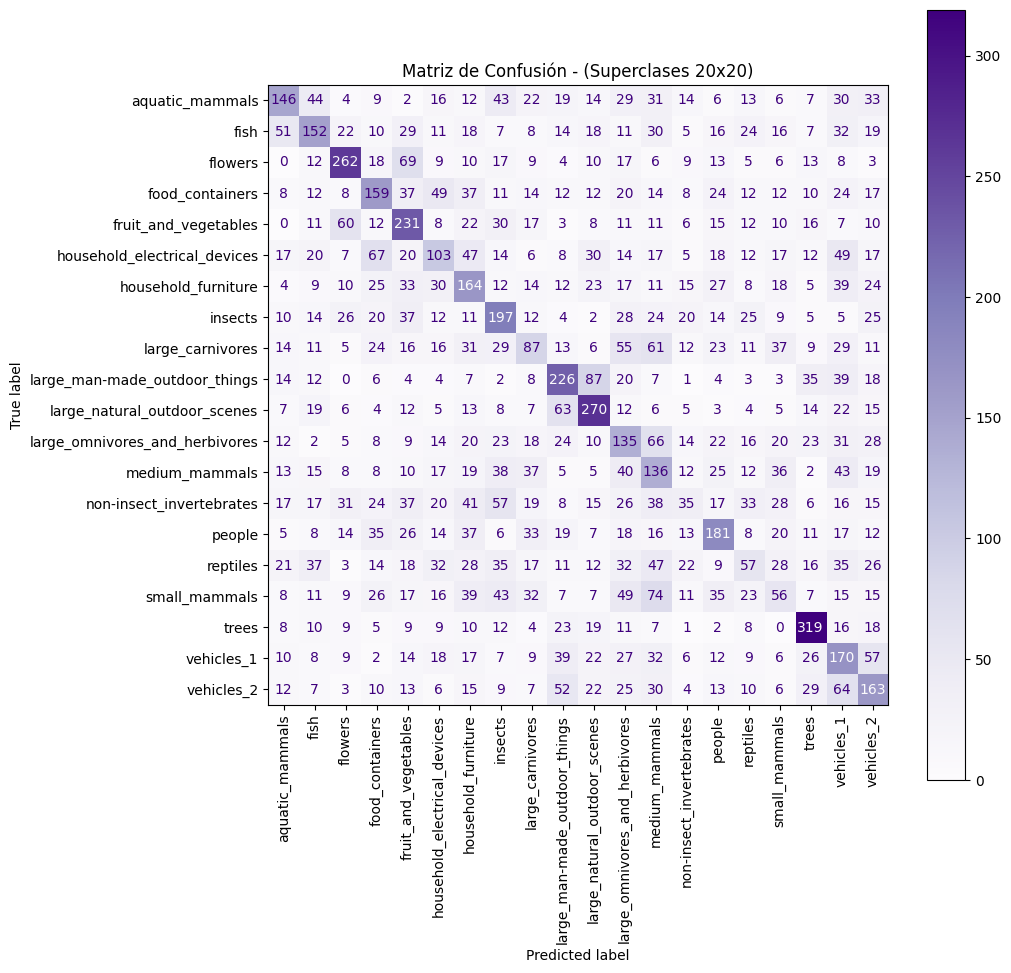

In [ ]:
print("Evaluando el modelo B (superclases) en el conjunto de Test...")

y_pred_B_coarse = []
y_test_B_coarse = []
for images, labels_fine, labels_coarse in test_loader:
  y_test_B_coarse.append(labels_coarse.cpu())
  y_pred_B_coarse.append(model_B(images).detach().cpu())

y_test_final = torch.cat(y_test_B_coarse)
y_pred_final = torch.argmax(torch.cat(y_pred_B_coarse), dim=-1)
coarse_class_names = coarse_class_names = [b.decode('utf-8') for b in meta_dict[b'coarse_label_names']]
cm = confusion_matrix(y_test_final, y_pred_final)
# 1. Creo la figura (fig) Y los ejes (ax) con el tamaño deseado
fig, ax = plt.subplots(figsize=(10, 10))

# 2. Creo el objeto ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=coarse_class_names)

# 3. Llamo a .plot() PASÁNDOLE LOS EJES (ax=ax)
disp.plot(xticks_rotation='vertical', cmap='Purples', ax=ax)

ax.set_title("Matriz de Confusión - (Superclases 20x20)")